In [56]:
import pandas as pd
# Librerías para datos y gráficos
import numpy as np          # Para trabajar con arreglos numéricos
import pandas as pd         # Para manejar tablas de datos (DataFrames)
import matplotlib.pyplot as plt  # Para hacer gráficos
import seaborn as sns

from sklearn.feature_selection import chi2

# Herramientas de machine learning (scikit-learn)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc                       # Medir calidad de los modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Modelos de árboles

# Para análisis de supervivencia
from lifelines import KaplanMeierFitter                                       # Para crear curvas de supervivencia
from lifelines.statistics import logrank_test                                 # Prueba para comparar curvas
from sksurv.ensemble import RandomSurvivalForest                              # Modelo de bosque para supervivencia
from sksurv.util import Surv                                                   # Formato de datos para supervivencia
from sksurv.metrics import concordance_index_censored                        # Medida para evaluar modelos de supervivencia

# Para balancear datos y generar muestras nuevas
from imblearn.over_sampling import SMOTE                                   # Para balancear datos desbalanceados

# Para usar XGBoost, un modelo potente basado en árboles
import xgboost as xgb     
from xgboost import XGBClassifier     

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [57]:
top25_genes = [
    "CD74",
    "HLA-DPB1",
    "HLA-DRB1",
    "HLA-DMA",
    "HLA-DMB",
    "HLA-DRA",
    "HLA-DPA1",
    "HLA-DOA",
    "HLA-E",
    "HLA-DQA1",
    "PTPRC",
    "LYN",
    "IL10",
    "CD3E",
    "FCGR3A",
    "LCK",
    "CASP1",
    "CD2",
    "B2M",
    "LCP2",
    "SERPING1",
    "CD4",
    "FCER1G",
    "C1QB",
    "C1QC"
]

In [58]:
top25_genes = [
    'CD74', 'HLA-DPB1', 'HLA-DRB1', 'HLA-DMA', 'HLA-DMB', 'HLA-DRA', 'HLA-DPA1', 'HLA-DOA', 'HLA-E', 'HLA-DQA1', 'PTPRC', 'LYN', 'IL10', 'CD3E', 'FCGR3A', 'LCK', 'CASP1', 'CD2', 'B2M', 'LCP2', 'SERPING1', 'CD4', 'FCER1G', 'C1QB', 'C1QC', 'RUNX1', 'HLA-C', 'SYK', 'TIMP1', 'CD44', 'MMP14', 'IL7R', 'COL1A2', 'ISG15', 'IFI44L', 'RSAD2', 'MAOB', 'CASP4', 'CCR5', 'CASP8', 'CTSS', 'CCL5', 'DAPP1', 'HLA-B', 'ITGB2', 'ITGA5', 'PLCG2', 'TYROBP', 'ALOX5', 'LSP1', 'GZMA', 'HLA-DQB1', 'CCR2', 'CYBA', 'NCF1', 'CLEC7A', 'PTGS1', 'RIPK3', 'IL2RB', 'PYGL', 'CD53', 'RUNX3', 'GZMK', 'LAPTM5', 'SPI1', 'ICAM1', 'CD3D', 'CD86', 'HAVCR2', 'ALPK1', 'PTPN22', 'TIFA', 'CXCR3', 'PTPN6', 'CCR1', 'C1S', 'C2', 'HCK', 'VAV1', 'ITGB3', 'PIK3R5', 'HLA-DQA2', 'RNASE2', 'BTK', 'ITGB7', 'LILRB2', 'ANG', 'HCST', 'FCGR2B', 'PIK3R6', 'ITK', 'TLR7', 'PRF1', 'GZMH', 'TLR3', 'IFIH1', 'HERC5', 'COL1A1', 'CD80', 'CD163', 'SERPINH1', 'JAK3', 'CCL2', 'LGALS9C', 'PDCD1', 'LUM', 'TNFRSF11B', 'TNFSF10', 'XAF1', 'COL6A2', 'IFI44', 'ZBP1', 'PHEX', 'ENPP1', 'IRF7', 'SERPINE1', 'GZMB', 'GNLY', 'CXCR2', 'F3', 'CXCR4', 'VCAM1', 'IL6', 'EGR1', 'MMP9', 'FCAR', 'PIGR', 'ALDH3A1', 'AOX1', 'EGR2', 'IBSP', 'CEP55', 'KIF2C', 'HOXD11', 'HOXD10', 'PLBD1', 'SP100', 'CIITA', 'ADPRH', 'KYNU', 'SERPINA1', 'SQRDL', 'MSR1', 'S100A4', 'RAC2', 'FAM129A', 'S100A11', 'GPR65', 'CLIC1', 'PTGER4', 'IL2RG', 'GBP5', 'TRIM38', 'FGL2', 'CTSC', 'APOBEC3G', 'FCGR2A', 'IFI30', 'DENND2D', 'ARHGAP15', 'LTBR', 'TNFAIP8', 'CECR1', 'PLSCR1', 'MSN', 'FCGR2C', 'ELF4', 'ITGAL', 'CD7', 'MYOF', 'ARHGAP25', 'SP140L'
]

In [59]:
path_rppa = '../data/Human__TCGA_LGG__MDA__RPPA__MDA_RPPA__01_28_2016__BI__Gene__Firehose_RPPA.cct.txt'
path_mutation = '../data/Human__TCGA_LGG__WUSM__Mutation__GAIIx__01_28_2016__BI__Gene__Firehose_MutSig2CV.cbt.txt'

path_scna_gen = '../data/Human__TCGA_LGG__BI__SCNA__SNP_6.0__01_28_2016__BI__Gene__Firehose_GISTIC2.cct'

rppa = pd.read_csv(path_rppa, sep='\t', index_col=0)
muta = pd.read_csv(path_mutation, sep='\t', index_col=0)
scna_gen = pd.read_csv(path_scna_gen, sep='\t', index_col=0)

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos rppa: (148, 429)
Dimensión datos mutaciones: (889, 513)
Dimensión datos scna: (24776, 513)


In [60]:
rppa = rppa.loc[rppa.index.isin(top25_genes)]
scna_gen = scna_gen.loc[scna_gen.index.isin(top25_genes)]
muta = muta.loc[muta.index.isin(top25_genes)]

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

print(scna_gen.index.tolist())

Dimensión datos rppa: (3, 429)
Dimensión datos mutaciones: (13, 513)
Dimensión datos scna: (158, 513)
['ISG15', 'C1QC', 'C1QB', 'RUNX3', 'LAPTM5', 'LCK', 'KIF2C', 'IFI44L', 'IFI44', 'GBP5', 'F3', 'VCAM1', 'CD53', 'DENND2D', 'PTPN22', 'CD2', 'CTSS', 'S100A11', 'S100A4', 'FCER1G', 'FCGR2A', 'FCGR2B', 'FCGR2C', 'FCGR3A', 'FAM129A', 'PTPRC', 'IL10', 'PIGR', 'RSAD2', 'ARHGAP25', 'GNLY', 'CXCR4', 'KYNU', 'ARHGAP15', 'IFIH1', 'HOXD10', 'HOXD11', 'AOX1', 'CASP8', 'CXCR2', 'SP140L', 'SP100', 'PDCD1', 'CCR1', 'CCR2', 'CCR5', 'CD80', 'ADPRH', 'CD86', 'PLSCR1', 'TNFSF10', 'IBSP', 'HERC5', 'DAPP1', 'TIFA', 'ALPK1', 'TLR3', 'IL7R', 'PTGER4', 'GZMK', 'GZMA', 'TNFAIP8', 'EGR1', 'CD74', 'HAVCR2', 'ITK', 'LCP2', 'TRIM38', 'C2', 'CLIC1', 'ENPP1', 'IL6', 'NCF1', 'FGL2', 'COL1A2', 'SERPINE1', 'MSR1', 'LYN', 'TNFRSF11B', 'SYK', 'PTGS1', 'ALOX5', 'EGR2', 'PRF1', 'MYOF', 'CEP55', 'IRF7', 'CD44', 'SPI1', 'SERPING1', 'SERPINH1', 'CTSC', 'CASP4', 'CASP1', 'CD3E', 'CD3D', 'LTBR', 'CD4', 'PTPN6', 'C1S', 'CD163', '

In [61]:
scna_gen = scna_gen.T 
scna_gen.head()

attrib_name,ISG15,C1QC,C1QB,RUNX3,LAPTM5,LCK,KIF2C,IFI44L,IFI44,GBP5,...,APOBEC3G,TLR7,PHEX,MAOB,TIMP1,MSN,IL2RG,CXCR3,BTK,ELF4
TCGA.CS.4938,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,...,0.011,-0.206,-0.206,-0.206,-0.206,0.123,0.123,0.123,0.123,0.123
TCGA.CS.4941,0.459,0.459,0.459,0.459,0.459,0.459,0.459,0.447,0.447,0.447,...,0.029,0.012,0.012,0.000,0.000,0.000,0.000,0.000,0.000,0.000
TCGA.CS.4942,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,0.025,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016
TCGA.CS.4943,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,...,-0.870,-0.084,-0.084,-0.084,-0.084,-0.084,-0.084,-0.084,-0.084,-0.084
TCGA.CS.4944,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,...,-0.027,-0.048,-0.048,-0.048,-0.048,-0.048,-0.048,-0.048,-0.048,-0.048


In [62]:
data_cox = pd.read_csv('../data/data_cox_with_survival3yr_ht.csv', index_col=0)
data_cox.head()


,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,FES,CST7,LCP1,GPSM3,overall_survival,status,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,6.7434,1.4213,9.3821,8.5820,3574.0,False,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.2961,4.7850,10.4500,9.5249,234.0,True,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,7.1965,3.3214,10.6753,9.9380,1335.0,True,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,6.9534,2.1975,9.4071,8.5049,1106.0,True,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,6.5437,4.0117,9.5651,8.7404,1828.0,False,1,1.0,0.0,0.0


In [63]:
# Renombrar columnas de SCNA para indicar origen "_scna"
scna_renamed = scna_gen.add_suffix('_scna')

# Renombrar columnas de expresión para indicar origen "_expression"
cox_renamed = data_cox.add_suffix('_expression')

# Mantener la columna survival_3yr sin sufijo
survival_col = data_cox['survival_3yr']

# Encontrar genes comunes
genes_cox = set([col.replace('_expression', '') for col in cox_renamed.columns])
genes_scna = set([col.replace('_scna', '') for col in scna_renamed.columns])
common_genes = genes_cox.intersection(genes_scna)

# Filtrar matrices por genes comunes
cols_cox_common = [gene + '_expression' for gene in common_genes]
cols_scna_common = [gene + '_scna' for gene in common_genes]

cox_filtered = cox_renamed[cols_cox_common]
scna_filtered = scna_renamed[cols_scna_common]

# Unir por índice de muestra
merged_data = pd.merge(cox_filtered, scna_filtered, left_index=True, right_index=True, how='inner')

# Añadir la columna survival_3yr
merged_data = merged_data.join(survival_col, how='inner')

# Ordenar columnas: expresión y SCNA lado a lado por gen
ordered_cols = []
for gene in sorted(common_genes):
    ordered_cols.append(gene + '_expression')
    ordered_cols.append(gene + '_scna')
ordered_cols.append('survival_3yr')

merged_data = merged_data[ordered_cols]

# Vista final
print(merged_data.head())



              ADPRH_expression  ADPRH_scna  ALDH3A1_expression  ALDH3A1_scna  \
TCGA.CS.4938            6.4638       0.001              2.1231        -0.001   
TCGA.CS.4941            8.7398       0.018              6.2522         0.016   
TCGA.CS.4942            7.7237      -0.009              1.2534         0.033   
TCGA.CS.4943            6.8714      -0.008              1.9763        -0.005   
TCGA.CS.4944            6.1822       0.015              4.1411        -0.016   

              ALOX5_expression  ALOX5_scna  ALPK1_expression  ALPK1_scna  \
TCGA.CS.4938            6.7825       0.002            6.1764      -0.004   
TCGA.CS.4941            8.8312      -0.584            7.3835      -0.017   
TCGA.CS.4942            8.3817      -0.004            7.5130      -0.021   
TCGA.CS.4943            7.7779       0.024            5.7414      -0.859   
TCGA.CS.4944            7.0946      -0.003            7.3343       0.017   

              ANG_expression  ANG_scna  ...  TYROBP_scna  VAV1

In [64]:
data_cox.head()

,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,FES,CST7,LCP1,GPSM3,overall_survival,status,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,6.7434,1.4213,9.3821,8.5820,3574.0,False,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.2961,4.7850,10.4500,9.5249,234.0,True,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,7.1965,3.3214,10.6753,9.9380,1335.0,True,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,6.9534,2.1975,9.4071,8.5049,1106.0,True,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,6.5437,4.0117,9.5651,8.7404,1828.0,False,1,1.0,0.0,0.0


In [65]:
merged_data.head()

,ADPRH_expression,ADPRH_scna,ALDH3A1_expression,ALDH3A1_scna,ALOX5_expression,ALOX5_scna,ALPK1_expression,ALPK1_scna,ANG_expression,ANG_scna,...,TYROBP_scna,VAV1_expression,VAV1_scna,VCAM1_expression,VCAM1_scna,XAF1_expression,XAF1_scna,ZBP1_expression,ZBP1_scna,survival_3yr
TCGA.CS.4938,6.4638,0.001,2.1231,-0.001,6.7825,0.002,6.1764,-0.004,4.2172,0.003,...,0.008,8.1719,0.008,11.8776,0.003,6.4638,-0.001,4.1523,0.765,1
TCGA.CS.4941,8.7398,0.018,6.2522,0.016,8.8312,-0.584,7.3835,-0.017,5.6640,-0.601,...,0.021,8.4262,0.021,10.3658,0.447,11.1263,0.016,6.4185,0.021,0
TCGA.CS.4942,7.7237,-0.009,1.2534,0.033,8.3817,-0.004,7.5130,-0.021,5.4590,0.021,...,0.020,8.6412,0.020,11.6062,0.002,9.2802,0.033,4.5959,0.019,1
TCGA.CS.4943,6.8714,-0.008,1.9763,-0.005,7.7779,0.024,5.7414,-0.859,3.8007,0.008,...,-0.276,7.6479,-0.041,10.6845,-0.043,6.4335,-0.005,1.3953,-0.043,1
TCGA.CS.4944,6.1822,0.015,4.1411,-0.016,7.0946,-0.003,7.3343,0.017,6.4809,0.004,...,0.609,7.3253,-0.015,8.0973,-0.677,6.4553,-0.016,5.0121,-0.027,1


In [66]:
# Selecciona las columnas histológicas codificadas
hist_cols = [col for col in data_cox.columns if col.startswith('histological_type')]

# Une las columnas histológicas a merged_data (por índice)
merged_data = merged_data.join(data_cox[hist_cols], how='inner')

In [67]:
merged_data.head()

,ADPRH_expression,ADPRH_scna,ALDH3A1_expression,ALDH3A1_scna,ALOX5_expression,ALOX5_scna,ALPK1_expression,ALPK1_scna,ANG_expression,ANG_scna,...,VCAM1_expression,VCAM1_scna,XAF1_expression,XAF1_scna,ZBP1_expression,ZBP1_scna,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,6.4638,0.001,2.1231,-0.001,6.7825,0.002,6.1764,-0.004,4.2172,0.003,...,11.8776,0.003,6.4638,-0.001,4.1523,0.765,1,1.0,0.0,0.0
TCGA.CS.4941,8.7398,0.018,6.2522,0.016,8.8312,-0.584,7.3835,-0.017,5.6640,-0.601,...,10.3658,0.447,11.1263,0.016,6.4185,0.021,0,1.0,0.0,0.0
TCGA.CS.4942,7.7237,-0.009,1.2534,0.033,8.3817,-0.004,7.5130,-0.021,5.4590,0.021,...,11.6062,0.002,9.2802,0.033,4.5959,0.019,1,1.0,0.0,0.0
TCGA.CS.4943,6.8714,-0.008,1.9763,-0.005,7.7779,0.024,5.7414,-0.859,3.8007,0.008,...,10.6845,-0.043,6.4335,-0.005,1.3953,-0.043,1,1.0,0.0,0.0
TCGA.CS.4944,6.1822,0.015,4.1411,-0.016,7.0946,-0.003,7.3343,0.017,6.4809,0.004,...,8.0973,-0.677,6.4553,-0.016,5.0121,-0.027,1,1.0,0.0,0.0


In [68]:
# Mover la columna 'survival_3yr' al final del DataFrame
cols = [col for col in merged_data.columns if col != 'survival_3yr'] + ['survival_3yr']
merged_data = merged_data[cols]


In [69]:
merged_data.head()

,ADPRH_expression,ADPRH_scna,ALDH3A1_expression,ALDH3A1_scna,ALOX5_expression,ALOX5_scna,ALPK1_expression,ALPK1_scna,ANG_expression,ANG_scna,...,VCAM1_expression,VCAM1_scna,XAF1_expression,XAF1_scna,ZBP1_expression,ZBP1_scna,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,survival_3yr
TCGA.CS.4938,6.4638,0.001,2.1231,-0.001,6.7825,0.002,6.1764,-0.004,4.2172,0.003,...,11.8776,0.003,6.4638,-0.001,4.1523,0.765,1.0,0.0,0.0,1
TCGA.CS.4941,8.7398,0.018,6.2522,0.016,8.8312,-0.584,7.3835,-0.017,5.6640,-0.601,...,10.3658,0.447,11.1263,0.016,6.4185,0.021,1.0,0.0,0.0,0
TCGA.CS.4942,7.7237,-0.009,1.2534,0.033,8.3817,-0.004,7.5130,-0.021,5.4590,0.021,...,11.6062,0.002,9.2802,0.033,4.5959,0.019,1.0,0.0,0.0,1
TCGA.CS.4943,6.8714,-0.008,1.9763,-0.005,7.7779,0.024,5.7414,-0.859,3.8007,0.008,...,10.6845,-0.043,6.4335,-0.005,1.3953,-0.043,1.0,0.0,0.0,1
TCGA.CS.4944,6.1822,0.015,4.1411,-0.016,7.0946,-0.003,7.3343,0.017,6.4809,0.004,...,8.0973,-0.677,6.4553,-0.016,5.0121,-0.027,1.0,0.0,0.0,1


## EDA

In [70]:
# General info
print("Resumen de tipos de datos y valores no nulos:")
print(merged_data.info())

print("\nDescriptivo general:")
print(merged_data.describe(include='all'))

print("\nPrimeras filas del DataFrame:")
print(merged_data.head())

print("\nConteo de valores para la variable objetivo:")
print(merged_data['survival_3yr'].value_counts())

Resumen de tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 478 entries, TCGA.CS.4938 to TCGA.WY.A85E
Columns: 320 entries, ADPRH_expression to survival_3yr
dtypes: float64(319), int64(1)
memory usage: 1.2+ MB
None

Descriptivo general:
       ADPRH_expression  ADPRH_scna  ALDH3A1_expression  ALDH3A1_scna  \
count        478.000000  478.000000          478.000000    478.000000   
mean           6.684442   -0.030174            2.349677      0.022004   
std            0.903346    0.149893            1.620670      0.121027   
min            4.189300   -0.969000            0.000000     -0.900000   
25%            6.052700   -0.006000            1.252125     -0.004000   
50%            6.620800    0.000000            2.015700      0.015000   
75%            7.244325    0.006000            3.054250      0.051000   
max            9.336300    0.767000           10.149900      1.318000   

       ALOX5_expression  ALOX5_scna  ALPK1_expression  ALPK1_scna  \
count

In [71]:
# Visualización de la variable objetivo
'''sns.countplot(x='survival_3yr', data=merged_data)
plt.title('Distribución de la variable objetivo: survival_3yr')
plt.show()'''

"sns.countplot(x='survival_3yr', data=merged_data)\nplt.title('Distribución de la variable objetivo: survival_3yr')\nplt.show()"

In [72]:
'''merged_data_rs.hist(bins=30, figsize=(18, 12))
plt.suptitle('Histogramas variables numéricas')
plt.show()'''

"merged_data_rs.hist(bins=30, figsize=(18, 12))\nplt.suptitle('Histogramas variables numéricas')\nplt.show()"

In [73]:
# Boxplots para variables numéricas vs target
num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
'''for col in num_cols:
    if col != 'survival_3yr':
        sns.boxplot(x='survival_3yr', y=col, data=merged_data)
        plt.title(f'Boxplot de {col} por survival_3yr')
        plt.show()'''

"for col in num_cols:\n    if col != 'survival_3yr':\n        sns.boxplot(x='survival_3yr', y=col, data=merged_data)\n        plt.title(f'Boxplot de {col} por survival_3yr')\n        plt.show()"

In [74]:
# Correlación de variables numéricas
'''plt.figure(figsize=(20, 18))
sns.heatmap(merged_data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()'''

"plt.figure(figsize=(20, 18))\nsns.heatmap(merged_data[num_cols].corr(), annot=True, cmap='coolwarm')\nplt.title('Matriz de correlación')\nplt.show()"

In [75]:
# Filtrar columnas que empiezan con 'histological_type'
'''hist_cols = [col for col in merged_data.columns if col.startswith('histological_type')]

for col in hist_cols:
    print(f"\nValor de conteos en {col}:")
    print(merged_data[col].value_counts())
    sns.countplot(x=col, data=merged_data, hue='survival_3yr')
    plt.title(f'{col} por survival_3yr')
    plt.xticks(rotation=45)
    plt.show()'''


'hist_cols = [col for col in merged_data.columns if col.startswith(\'histological_type\')]\n\nfor col in hist_cols:\n    print(f"\nValor de conteos en {col}:")\n    print(merged_data[col].value_counts())\n    sns.countplot(x=col, data=merged_data, hue=\'survival_3yr\')\n    plt.title(f\'{col} por survival_3yr\')\n    plt.xticks(rotation=45)\n    plt.show()'

In [76]:
#Correlación de Pearson para variables numéricas
'''num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
if 'survival_3yr' in num_cols:
    num_cols = num_cols.drop('survival_3yr')  # Evita autoco-correlación

correlations = merged_data[num_cols].corrwith(merged_data['survival_3yr']).abs().sort_values(ascending=False)
print("Correlaciones con survival_3yr:")
print(correlations)'''

'num_cols = merged_data.select_dtypes(include=[\'float64\', \'int\']).columns\nif \'survival_3yr\' in num_cols:\n    num_cols = num_cols.drop(\'survival_3yr\')  # Evita autoco-correlación\n\ncorrelations = merged_data[num_cols].corrwith(merged_data[\'survival_3yr\']).abs().sort_values(ascending=False)\nprint("Correlaciones con survival_3yr:")\nprint(correlations)'

In [77]:
#Importancia según RandomForest (considerando todas las variables)
'''X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

# Ya no aplicamos get_dummies porque las columnas histological_type ya están como one-hot
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)
print("Importancia según RandomForest:")
print(importancias)'''

'X = merged_data.drop(\'survival_3yr\', axis=1)\ny = merged_data[\'survival_3yr\']\n\n# Ya no aplicamos get_dummies porque las columnas histological_type ya están como one-hot\nrf = RandomForestClassifier(n_estimators=100, random_state=42)\nrf.fit(X, y)\n\nimportancias = pd.Series(rf.feature_importances_, index=X.columns)\nimportancias = importancias.sort_values(ascending=False)\nprint("Importancia según RandomForest:")\nprint(importancias)'

In [78]:
# Visualización
'''importancias.head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 características más importantes (RandomForest)')
plt.gca().invert_yaxis()
plt.show()'''

"importancias.head(20).plot(kind='barh', figsize=(8, 6))\nplt.title('Top 20 características más importantes (RandomForest)')\nplt.gca().invert_yaxis()\nplt.show()"

In [79]:
#Chi-cuadrado para variables categóricas (one-hot de histological_type)

'''if hist_cols:
    chi_scores = chi2(merged_data[hist_cols], y)
    chi2_df = pd.DataFrame({'Feature': hist_cols, 'Chi2 Score': chi_scores[0]})
    chi2_df = chi2_df.sort_values('Chi2 Score', ascending=False)
    print("Chi-cuadrado para variables histological_type:")
    print(chi2_df.head(10))
else:
    print("No se encontraron columnas que empiecen con 'histological_type' para análisis chi-cuadrado.")'''

'if hist_cols:\n    chi_scores = chi2(merged_data[hist_cols], y)\n    chi2_df = pd.DataFrame({\'Feature\': hist_cols, \'Chi2 Score\': chi_scores[0]})\n    chi2_df = chi2_df.sort_values(\'Chi2 Score\', ascending=False)\n    print("Chi-cuadrado para variables histological_type:")\n    print(chi2_df.head(10))\nelse:\n    print("No se encontraron columnas que empiecen con \'histological_type\' para análisis chi-cuadrado.")'

## Modelos

In [80]:
# Función para evaluar modelo y obtener AUC
def evaluar_modelo(modelo, X, y, cv):
    auc_scores = []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        auc_scores.append(auc)

    return auc_scores, y_test, y_proba

In [81]:
from imblearn.over_sampling import RandomOverSampler, ADASYN, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek


# Ejemplos
ros = RandomOverSampler(random_state=42)
adasyn = ADASYN(random_state=42)
smoteenn = SMOTEENN(random_state=42)
smotetomek = SMOTETomek(random_state=42)
rus = RandomUnderSampler(random_state=42)

In [82]:
X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
# validacion cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote, y_train_smote = ros.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = adasyn.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = smoteenn.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = smotetomek.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = rus.fit_resample(X_train, y_train)
# sin smote
#X_train_smote, y_train_smote = X_train, y_train

[LightGBM] [Info] Number of positive: 257, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40393
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 319
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

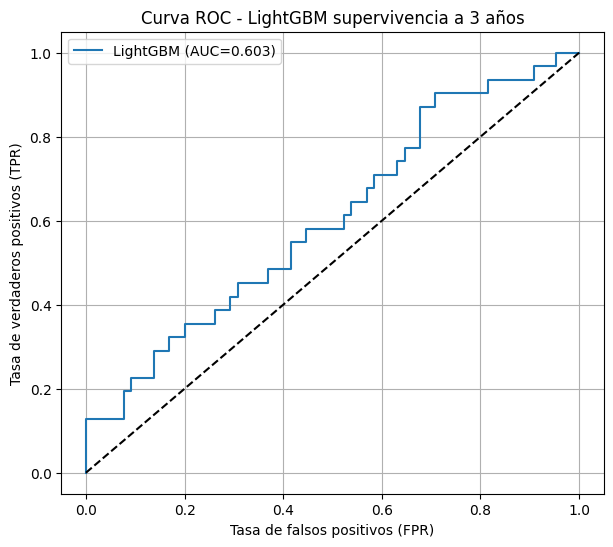

In [83]:
# Entrenamiento
lgbm_clf = LGBMClassifier(random_state=42, colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, num_leaves=31, subsample=0.8)
lgbm_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento SMOTE
y_pred_train = lgbm_clf.predict_proba(X_train_smote)[:,1]
auc_train = roc_auc_score(y_train_smote, y_pred_train)
print(f"AUC ROC entrenamiento (SMOTE): {auc_train:.4f}")

# Métricas en test (original)
y_pred_test = lgbm_clf.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_pred_test)
print(f"AUC ROC test: {auc_test:.4f}")

# Curva ROC para test
fpr, tpr, _ = roc_curve(y_test, y_pred_test)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC={auc_test:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - LightGBM supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento (SMOTE): 1.0000
AUC ROC test: 0.6119


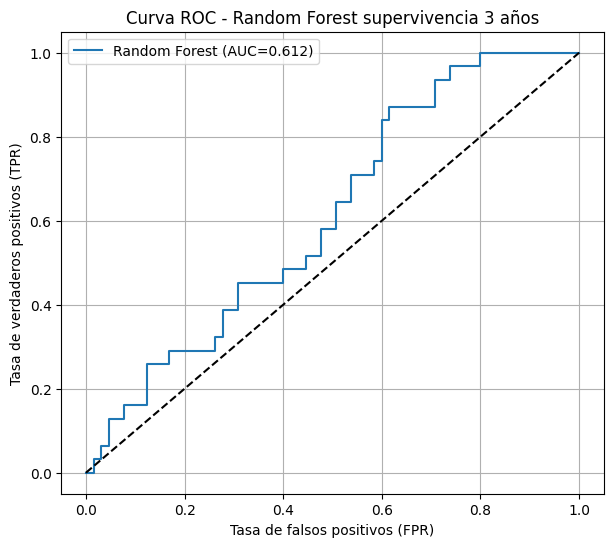

In [84]:
# Entrenamiento Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=1, max_features=0.3, max_depth=None, bootstrap=False)
rf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_rf = rf.predict_proba(X_train_smote)[:,1]
auc_train_rf = roc_auc_score(y_train_smote, y_pred_train_rf)
print(f"AUC ROC entrenamiento (SMOTE): {auc_train_rf:.4f}")

# Métricas en test original
y_pred_test_rf = rf.predict_proba(X_test)[:,1]
auc_test_rf = roc_auc_score(y_test, y_pred_test_rf)
print(f"AUC ROC test: {auc_test_rf:.4f}")

# Curva ROC para test
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_test_rf)
plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_test_rf:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest supervivencia 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento (SMOTE): 1.0000
AUC ROC test: 0.6447


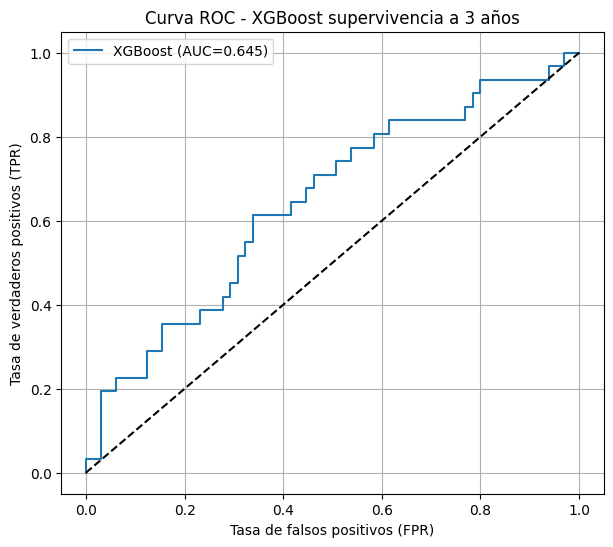

In [85]:
# Entrenamiento XGBoost
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    colsample_bytree=0.6,
    gamma=0,
    random_state=42
)
xgb_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_xgb = xgb_clf.predict_proba(X_train_smote)[:,1]
auc_train_xgb = roc_auc_score(y_train_smote, y_pred_train_xgb)
print(f"AUC ROC entrenamiento (SMOTE): {auc_train_xgb:.4f}")

# Métricas en test original
y_pred_test_xgb = xgb_clf.predict_proba(X_test)[:,1]
auc_test_xgb = roc_auc_score(y_test, y_pred_test_xgb)
print(f"AUC ROC test: {auc_test_xgb:.4f}")

# Curva ROC en test
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_test_xgb)
plt.figure(figsize=(7,6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_test_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - XGBoost supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento (SMOTE): 1.0000
AUC ROC test: 0.6342


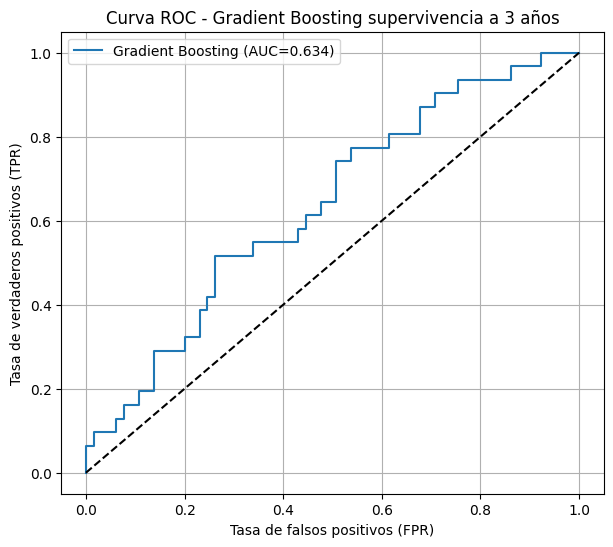

In [86]:
# Entrenamiento Gradient Boosting
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    random_state=42,
    max_features= 'sqrt',
    min_samples_leaf=2,
    min_samples_split=5
)
gb_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_gb = gb_clf.predict_proba(X_train_smote)[:,1]
auc_train_gb = roc_auc_score(y_train_smote, y_pred_train_gb)
print(f"AUC ROC entrenamiento (SMOTE): {auc_train_gb:.4f}")

# Métricas en test original
y_pred_test_gb = gb_clf.predict_proba(X_test)[:,1]
auc_test_gb = roc_auc_score(y_test, y_pred_test_gb)
print(f"AUC ROC test: {auc_test_gb:.4f}")

# Curva ROC en test
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_test_gb)
plt.figure(figsize=(7,6))
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_test_gb:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Gradient Boosting supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()


AUC ROC Voting Ensemble (test): 0.6273


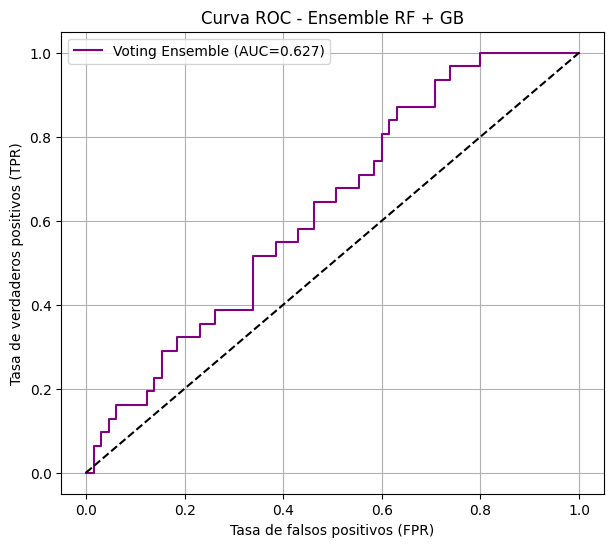

In [87]:
from sklearn.ensemble import VotingClassifier

# Instanciar con tus modelos ya entrenados (o inicializados con los mismos parámetros)
ensemble_voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb_clf)
    ],
    voting='soft'        # soft usa las probabilidades, hard usa clases
)

ensemble_voting.fit(X_train_smote, y_train_smote)

# Métricas en test
y_pred_test_ens = ensemble_voting.predict_proba(X_test)[:,1]
auc_test_ens = roc_auc_score(y_test, y_pred_test_ens)
print(f"AUC ROC Voting Ensemble (test): {auc_test_ens:.4f}")

fpr_ens, tpr_ens, _ = roc_curve(y_test, y_pred_test_ens)
plt.figure(figsize=(7,6))
plt.plot(fpr_ens, tpr_ens, label=f'Voting Ensemble (AUC={auc_test_ens:.3f})', color='purple')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Ensemble RF + GB')
plt.legend()
plt.grid(True)
plt.show()


[LightGBM] [Info] Number of positive: 257, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40393
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 319
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


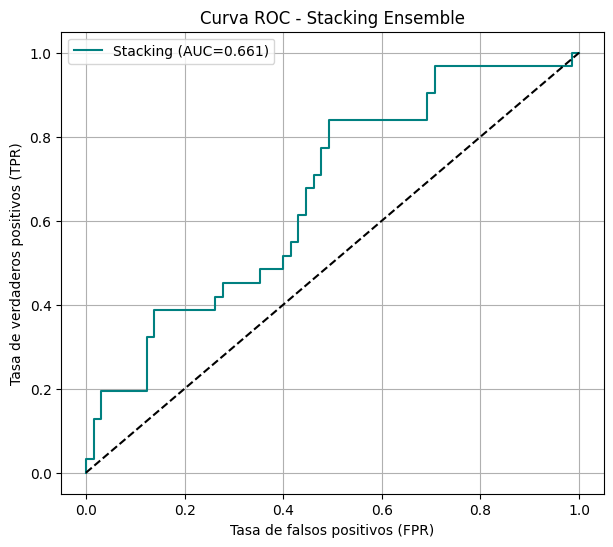

In [88]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Stack tus modelos base y un meta-modelo (lo habitual: regresión logística)
stack_clf = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb_clf),
        ('xgb', xgb_clf),
        ('lgbm', lgbm_clf)
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5,          # validación interna de meta-modelo, puedes ajustar
    passthrough=True   # incluye X original en meta-modelo
)

stack_clf.fit(X_train_smote, y_train_smote)

# Métricas en test stacking
y_pred_test_stack = stack_clf.predict_proba(X_test)[:,1]
auc_test_stack = roc_auc_score(y_test, y_pred_test_stack)
print(f"AUC ROC Stacking Ensemble (test): {auc_test_stack:.4f}")

fpr_stack, tpr_stack, _ = roc_curve(y_test, y_pred_test_stack)
plt.figure(figsize=(7,6))
plt.plot(fpr_stack, tpr_stack, label=f'Stacking (AUC={auc_test_stack:.3f})', color='teal')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()


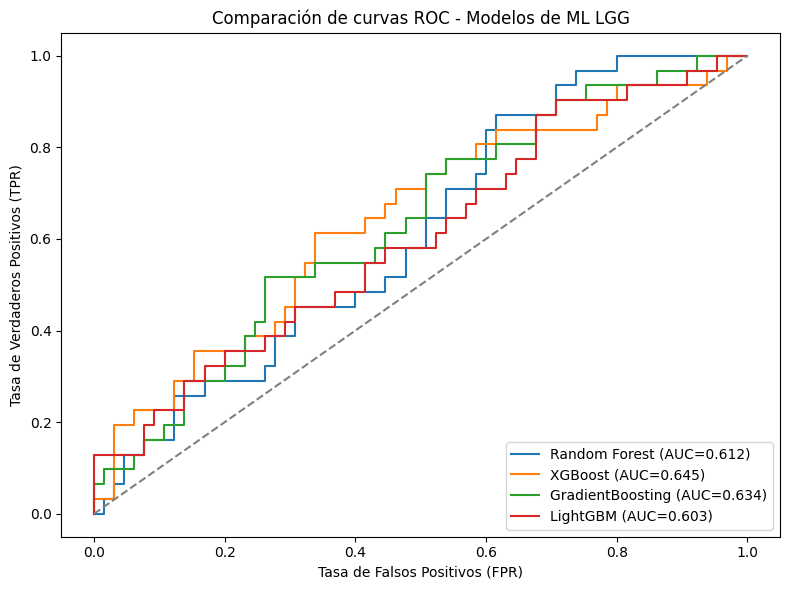

In [89]:
# Curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_test_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_test_xgb)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_test_gb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_test)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_gb = auc(fpr_gb, tpr_gb)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'GradientBoosting (AUC={auc_gb:.3f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC={auc_lgbm:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de curvas ROC - Modelos de ML LGG')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
